In [3]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LogNorm

In [2]:
file_mono = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7270229/cevns_full_source_mono_00.root")
tree_mono = file_mono["Primary"]
tree2_mono = file_mono["PrimaryPhononTracks"]
tree3_mono = file_mono["SecondaryPhononTracks"]

df_mono = tree_mono.arrays(library="pd")
df2_mono = tree2_mono.arrays(library="pd")
df3_mono = tree3_mono.arrays(library="pd")

#print((df2_mono['EventID']).value_counts().get(1,0))
#print((df2_mono['EventID']).value_counts().get(4,0))
#print((df2_mono['EventID']).value_counts().get(6,0))

df2_mono['CreatorProcess'] = df2_mono['CreatorProcess'].astype(str)
df3_mono['CreatorProcess'] = df3_mono['CreatorProcess'].astype(str)

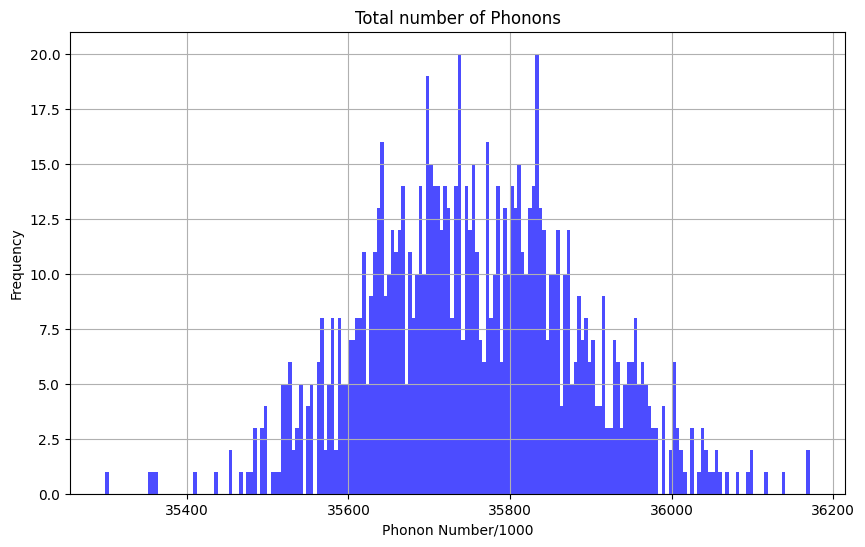

ValueError: Too many bins for data range. Cannot create 10 finite-sized bins.

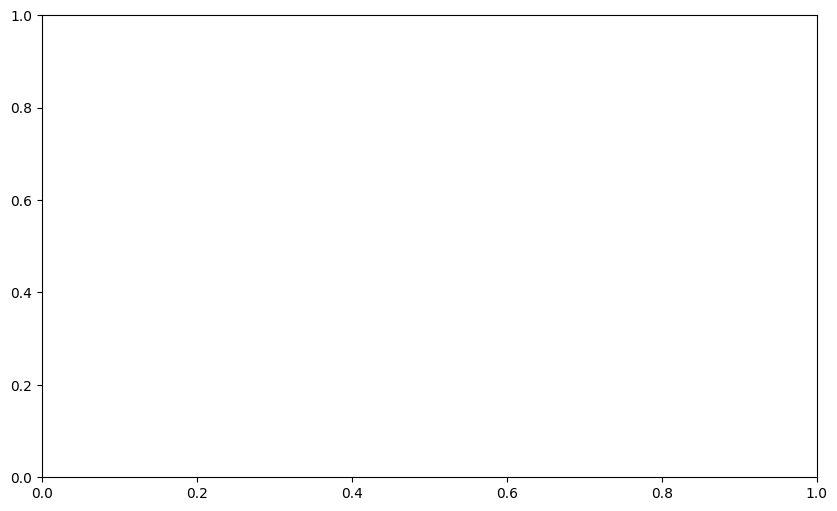

In [3]:
plt.figure(figsize=(10, 6))
plt.hist(df_mono['totalPhonons'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Phonons')
plt.xlabel('Phonon Number/1000')
plt.ylabel('Frequency')
plt.grid()
plt.savefig("CEvNS_full_phonon_number_mono.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2_mono['StartEnergy'], color='blue', alpha=0.7)
plt.title('Total number of Primary Phonons')
plt.xlabel('Phonon Energy')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_full_primary_phonon_energy_mono_updatedDebyeTemp.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df3_mono['StartEnergy'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Secondary Phonons')
plt.xlabel('Phonon Energy')
plt.ylabel('Number of Phonons/1000')
plt.yscale('log')
plt.grid()
plt.savefig("CEvNS_full_secondary_phonon_energy_mono_updatedDebyeTemp.pdf")
plt.show()

In [15]:
#print(df3_mono)

mask_dc = df3_mono['CreatorProcess'].str.contains('downConversion', case=False, na=False)
df3_mask_dc = df3_mono[mask_dc]

print(df3_mask_dc)


          EventID  TrackID  ParticleName   StartEnergy     StartMomX  \
1             0.0    489.0      phononTF  7.263415e-09 -1.524290e-09   
2             0.0    490.0      phononTS  4.873662e-09  4.861748e-09   
3             0.0    491.0      phononTS  2.631779e-09  1.624909e-09   
4             0.0    492.0      phononTF  4.631636e-09  1.721076e-09   
5             0.0    493.0      phononTF  2.779716e-09 -9.193365e-12   
...           ...      ...           ...           ...           ...   
35296255    999.0  35935.0      phononTS  2.658054e-09  1.656816e-09   
35296256    999.0  35936.0      phononTS  2.965726e-09 -1.914962e-09   
35296257    999.0  35937.0       phononL  5.008393e-09  3.344972e-09   
35296258    999.0  35938.0      phononTF  2.699361e-09  4.167518e-10   
35296259    999.0  35939.0      phononTF  2.309031e-09  1.327913e-09   

             StartMomY     StartMomZ        CreatorProcess  
1        -1.732881e-09  6.887007e-09  phononDownconversion  
2        -1.3

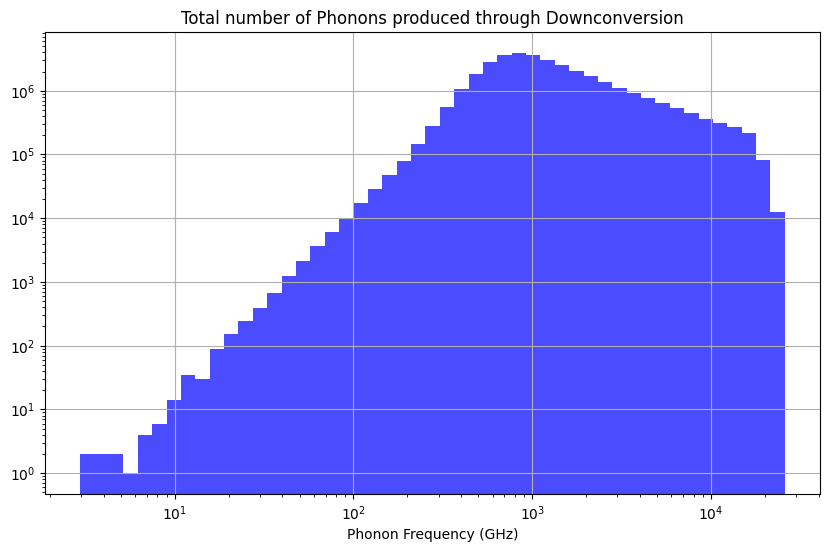

In [14]:
GHz_to_meV = 4.13*1e-3

min = np.min(df3_mask_dc['StartEnergy']*1e9/GHz_to_meV)
max = np.max(df3_mask_dc['StartEnergy']*1e9/GHz_to_meV)
bins = np.logspace(np.log10(min), np.log10(max), num=50)

plt.figure(figsize=(10, 6))
plt.hist(df3_mask_dc['StartEnergy']*1e9/GHz_to_meV, bins=bins, color='blue', alpha=0.7)
plt.title('Total number of Phonons produced through Downconversion')
plt.xlabel('Phonon Frequency (GHz)')
plt.ylabel('')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.savefig("CEvNS_full_secondary_phonon_energy_mono_updatedDebyeTemp.pdf")
plt.show()

In [4]:
file = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7270239/cevns_full_source_00.root")
tree = file["Primary"]
tree2 = file["PrimaryPhononTracks"]
tree3 = file["SecondaryPhononTracks"]

df = tree.arrays(library="pd")
df2 = tree2.arrays(library="pd")
df3 = tree3.arrays(library="pd")

In [12]:
df2['CreatorProcess'] = df2['CreatorProcess'].astype(str)
df3['CreatorProcess'] = df3['CreatorProcess'].astype(str)

mask_dc = df3['CreatorProcess'].str.contains('downConversion', case=False, na=False)
df3_full_dc = df3[mask_dc]

mask_luke = df3['CreatorProcess'].str.contains('LukeScattering', case=False, na=False)
df3_full_luke = df3[mask_luke]

print(df3_full_dc)
print(df3_full_luke)

          EventID  TrackID  ParticleName   StartEnergy     StartMomX  \
0             0.0    553.0      phononTS  3.186622e-08 -8.901931e-09   
1             0.0    554.0      phononTF  7.566103e-08  3.489879e-08   
2             0.0    555.0      phononTS  4.280841e-08 -2.595289e-08   
3             0.0    556.0      phononTS  3.285262e-08  2.247608e-08   
4             0.0    557.0      phononTF  1.917483e-08  3.717912e-09   
...           ...      ...           ...           ...           ...   
26249470    999.0  37496.0      phononTF  2.963410e-09  1.805474e-09   
26249471    999.0  37497.0      phononTF  3.071182e-09 -2.653193e-09   
26249472    999.0  37498.0      phononTS  5.751219e-09  4.235701e-09   
26249473    999.0  37499.0      phononTF  3.348874e-09  1.149307e-09   
26249474    999.0  37500.0      phononTF  2.402345e-09  3.187366e-10   

             StartMomY     StartMomZ        CreatorProcess  
0        -5.294888e-09 -3.013596e-08  phononDownconversion  
1         6.5

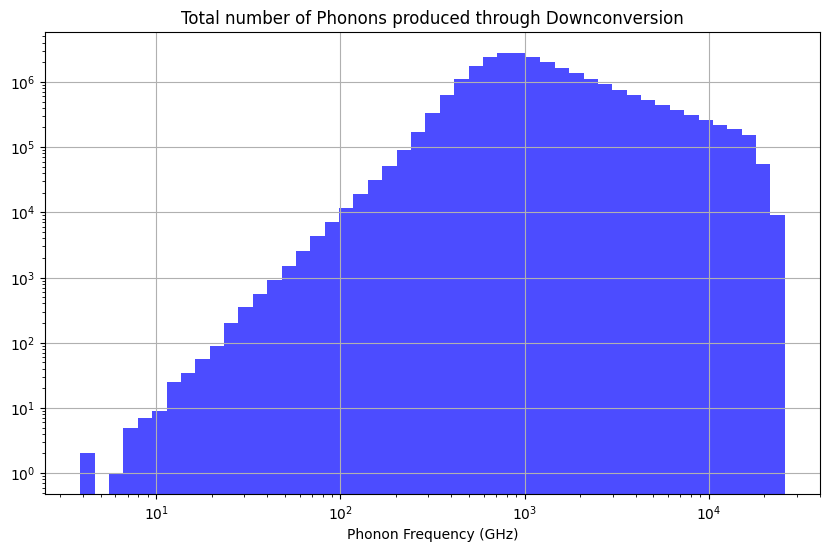

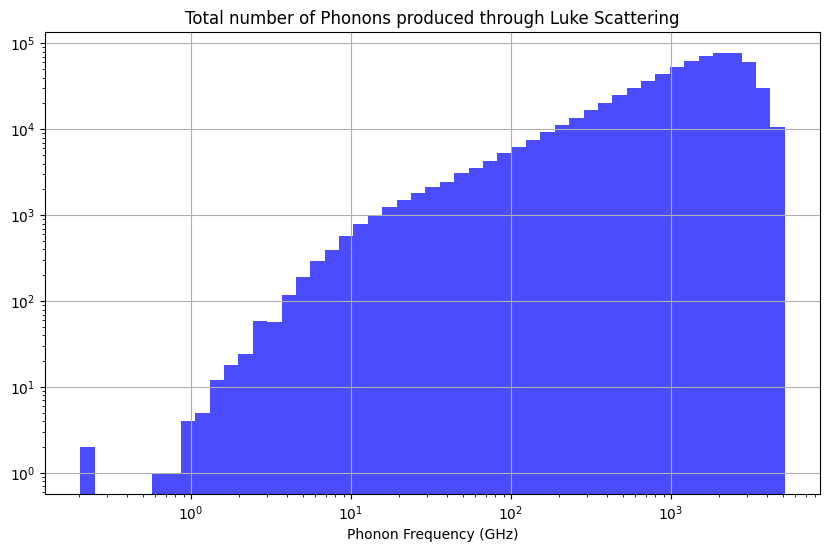

In [13]:
GHz_to_meV = 4.13*1e-3

min = np.min(df3_full_dc['StartEnergy']*1e9/GHz_to_meV)
max = np.max(df3_full_dc['StartEnergy']*1e9/GHz_to_meV)
bins = np.logspace(np.log10(min), np.log10(max), num=50)

plt.figure(figsize=(10, 6))
plt.hist(df3_full_dc['StartEnergy']*1e9/GHz_to_meV, bins=bins, color='blue', alpha=0.7)
plt.title('Total number of Phonons produced through Downconversion')
plt.xlabel('Phonon Frequency (GHz)')
plt.ylabel('')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.savefig("CEvNS_full_secondary_phonon_energy_spectrum_updatedDebyeTemp.pdf")
plt.show()

min = np.min(df3_full_luke['StartEnergy']*1e9/GHz_to_meV)
max = np.max(df3_full_luke['StartEnergy']*1e9/GHz_to_meV)
bins = np.logspace(np.log10(min), np.log10(max), num=50)

plt.figure(figsize=(10, 6))
plt.hist(df3_full_luke['StartEnergy']*1e9/GHz_to_meV, bins=bins, color='blue', alpha=0.7)
plt.title('Total number of Phonons produced through Luke Scattering')
plt.xlabel('Phonon Frequency (GHz)')
plt.ylabel('')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.savefig("CEvNS_LukeScattering_phonon_energy_spectrum_updatedDebyeTemp.pdf")
plt.show()

In [15]:
df3_full_dc['ParticleName'] = df3_full_dc['ParticleName'].astype(str)
mask_ts = df3_full_dc['ParticleName'].str.contains('PhononTS', case=False, na=False)
mask_tf = df3_full_dc['ParticleName'].str.contains('PhononTF', case=False, na=False)
mask_l = df3_full_dc['ParticleName'].str.contains('PhononL', case=False, na=False)

df3_full_ts = df3_full_dc[mask_ts]
df3_full_tf = df3_full_dc[mask_tf]
df3_full_l = df3_full_dc[mask_l]

df3_full_luke['ParticleName'] = df3_full_luke['ParticleName'].astype(str)
mask_ts = df3_full_luke['ParticleName'].str.contains('PhononTS', case=False, na=False)
mask_tf = df3_full_luke['ParticleName'].str.contains('PhononTF', case=False, na=False)
mask_l = df3_full_luke['ParticleName'].str.contains('PhononL', case=False, na=False)

df3_luke_ts = df3_full_luke[mask_ts]
df3_luke_tf = df3_full_luke[mask_tf]
df3_luke_l = df3_full_luke[mask_l]



/tmp/ipykernel_1257319/2005896758.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3_full_dc['ParticleName'] = df3_full_dc['ParticleName'].astype(str)
/tmp/ipykernel_1257319/2005896758.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3_full_luke['ParticleName'] = df3_full_luke['ParticleName'].astype(str)


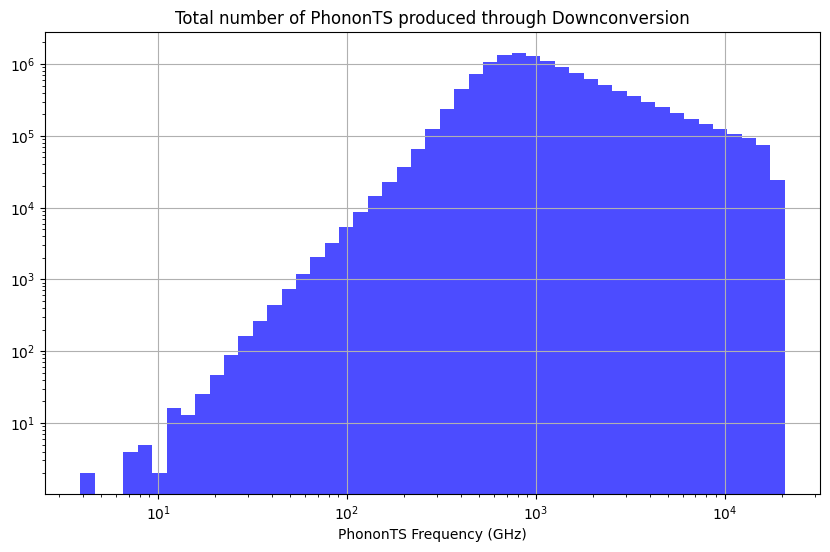

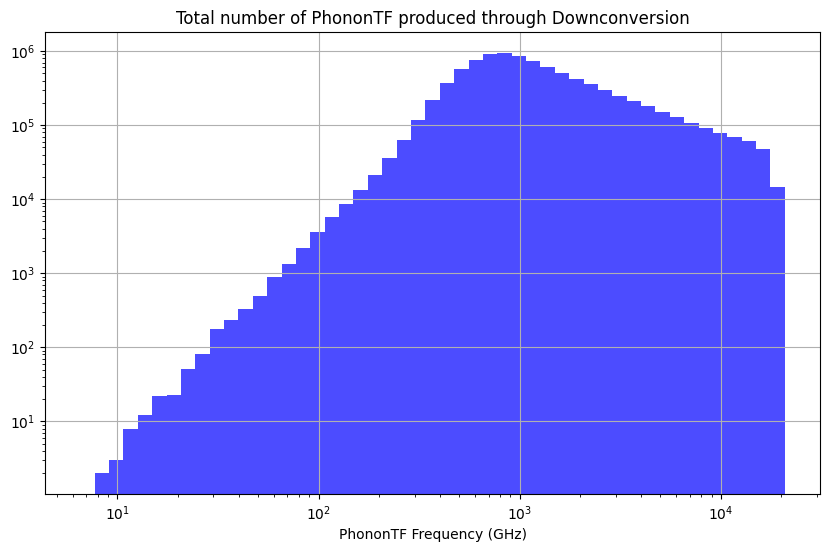

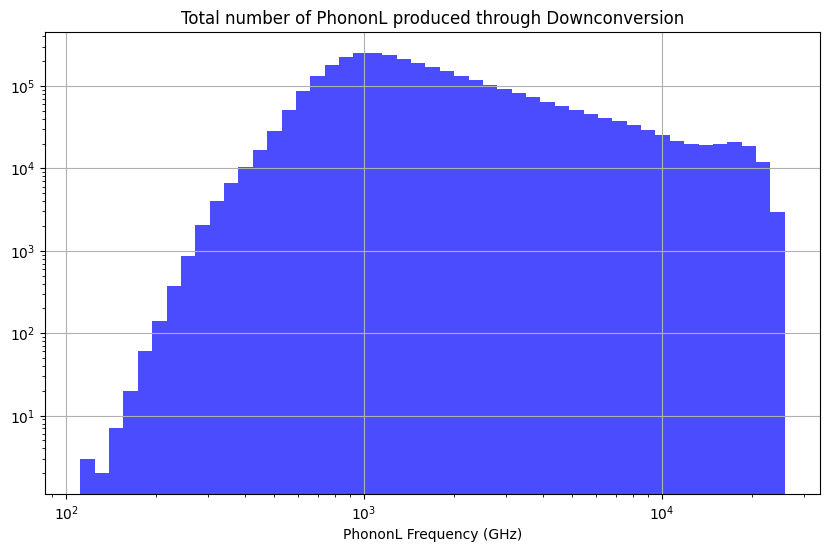

In [16]:
min = np.min(df3_full_ts['StartEnergy']*1e9/GHz_to_meV)
max = np.max(df3_full_ts['StartEnergy']*1e9/GHz_to_meV)
bins = np.logspace(np.log10(min), np.log10(max), num=50)

plt.figure(figsize=(10, 6))
plt.hist(df3_full_ts['StartEnergy']*1e9/GHz_to_meV, bins=bins, color='blue', alpha=0.7)
plt.title('Total number of PhononTS produced through Downconversion')
plt.xlabel('PhononTS Frequency (GHz)')
plt.ylabel('')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.savefig("CEvNS_phononTS_secondary_phonon_energy_spectrum_updatedDebyeTemp.pdf")
plt.show()

min = np.min(df3_full_tf['StartEnergy']*1e9/GHz_to_meV)
max = np.max(df3_full_tf['StartEnergy']*1e9/GHz_to_meV)
bins = np.logspace(np.log10(min), np.log10(max), num=50)

plt.figure(figsize=(10, 6))
plt.hist(df3_full_tf['StartEnergy']*1e9/GHz_to_meV, bins=bins, color='blue', alpha=0.7)
plt.title('Total number of PhononTF produced through Downconversion')
plt.xlabel('PhononTF Frequency (GHz)')
plt.ylabel('')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.savefig("CEvNS_phononTF_secondary_phonon_energy_spectrum_updatedDebyeTemp.pdf")
plt.show()

min = np.min(df3_full_l['StartEnergy']*1e9/GHz_to_meV)
max = np.max(df3_full_l['StartEnergy']*1e9/GHz_to_meV)
bins = np.logspace(np.log10(min), np.log10(max), num=50)

plt.figure(figsize=(10, 6))
plt.hist(df3_full_l['StartEnergy']*1e9/GHz_to_meV, bins=bins, color='blue', alpha=0.7)
plt.title('Total number of PhononL produced through Downconversion')
plt.xlabel('PhononL Frequency (GHz)')
plt.ylabel('')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.savefig("CEvNS_phononL_secondary_phonon_energy_spectrum_updatedDebyeTemp.pdf")
plt.show()


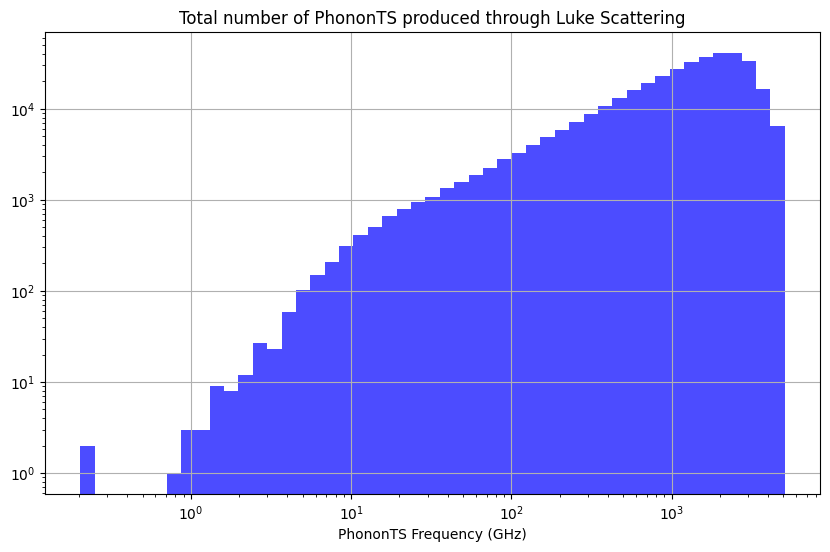

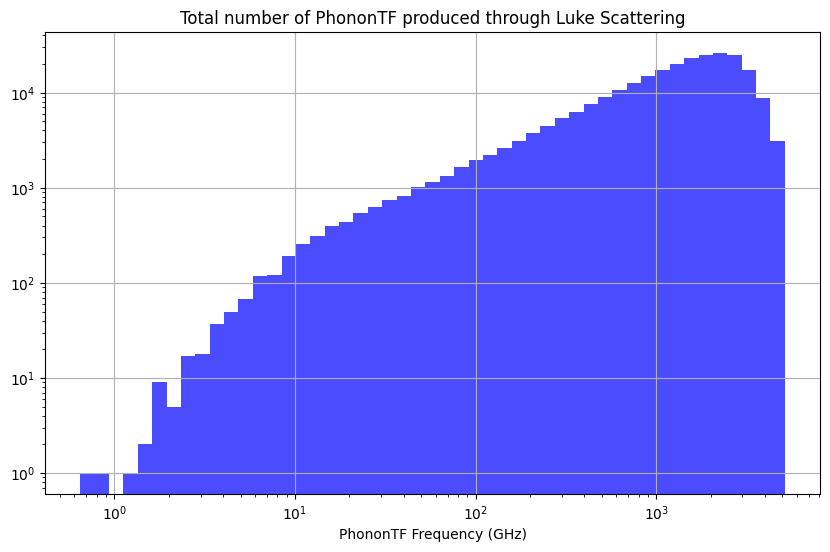

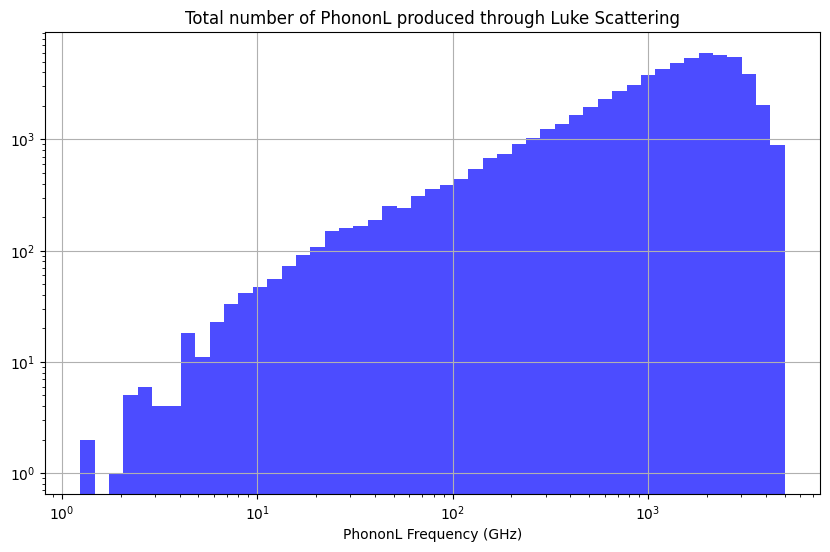

In [17]:
min = np.min(df3_luke_ts['StartEnergy']*1e9/GHz_to_meV)
max = np.max(df3_luke_ts['StartEnergy']*1e9/GHz_to_meV)
bins = np.logspace(np.log10(min), np.log10(max), num=50)

plt.figure(figsize=(10, 6))
plt.hist(df3_luke_ts['StartEnergy']*1e9/GHz_to_meV, bins=bins, color='blue', alpha=0.7)
plt.title('Total number of PhononTS produced through Luke Scattering')
plt.xlabel('PhononTS Frequency (GHz)')
plt.ylabel('')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.savefig("CEvNS_phononTS_LukeScattering_phonon_energy_spectrum_updatedDebyeTemp.pdf")
plt.show()

min = np.min(df3_luke_tf['StartEnergy']*1e9/GHz_to_meV)
max = np.max(df3_luke_tf['StartEnergy']*1e9/GHz_to_meV)
bins = np.logspace(np.log10(min), np.log10(max), num=50)

plt.figure(figsize=(10, 6))
plt.hist(df3_luke_tf['StartEnergy']*1e9/GHz_to_meV, bins=bins, color='blue', alpha=0.7)
plt.title('Total number of PhononTF produced through Luke Scattering')
plt.xlabel('PhononTF Frequency (GHz)')
plt.ylabel('')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.savefig("CEvNS_phononTF_LukeScattering_phonon_energy_spectrum_updatedDebyeTemp.pdf")
plt.show()

min = np.min(df3_luke_l['StartEnergy']*1e9/GHz_to_meV)
max = np.max(df3_luke_l['StartEnergy']*1e9/GHz_to_meV)
bins = np.logspace(np.log10(min), np.log10(max), num=50)

plt.figure(figsize=(10, 6))
plt.hist(df3_luke_l['StartEnergy']*1e9/GHz_to_meV, bins=bins, color='blue', alpha=0.7)
plt.title('Total number of PhononL produced through Luke Scattering')
plt.xlabel('PhononL Frequency (GHz)')
plt.ylabel('')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.savefig("CEvNS_phononL_LukeScattering_phonon_energy_spectrum_updatedDebyeTemp.pdf")
plt.show()
